# DIABETES CLASSIFICATION
# Healthy vs Prediabetes vs Diabetes

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### 1. LOAD THE DATASET

In [2]:
file_path = "diabetes_012_health_indicators_BRFSS2015.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

Dataset loaded successfully!

First 5 rows:
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15

### 2. CHECK THE TARGET VARIABLE

In [3]:
print("\nTarget variable:")
print(df["Diabetes_012"].value_counts().sort_index())

print("\nTarget labels:")
print("0 = Healthy")
print("1 = Prediabetes")
print("2 = Diabetes")


Target variable:
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

Target labels:
0 = Healthy
1 = Prediabetes
2 = Diabetes


### 3. CHECK FOR MISSING VALUES

In [4]:
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


### 4. SEPARATE FEATURES AND TARGET

In [5]:
X = df.drop("Diabetes_012", axis=1)

y = df["Diabetes_012"]


### 5. SPLIT DATA INTO TRAINING AND TESTING

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (202944, 21)
Testing data: (50736, 21)


### 6. STANDARDIZE THE FEATURES

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### 7. CREATE RANDOM FOREST CLASSIFIER

In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

### 8. TRAIN THE MODEL

In [9]:
print("\nTraining the model...")

model.fit(X_train, y_train)

print("Model training completed!")


Training the model...
Model training completed!


### 9. MAKE PREDICTIONS

In [10]:
y_pred = model.predict(X_test)

### 10. CALCULATE ACCURACY

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)

print("\nAccuracy percentage:")
print(accuracy * 100, "%")


Accuracy:
0.8429517502365185

Accuracy percentage:
84.29517502365185 %


### 11. CLASSIFICATION REPORT

In [12]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Healthy",
            "Prediabetes",
            "Diabetes"
        ]
    )
)


Classification Report:
              precision    recall  f1-score   support

     Healthy       0.86      0.97      0.91     42741
 Prediabetes       0.00      0.00      0.00       926
    Diabetes       0.50      0.20      0.29      7069

    accuracy                           0.84     50736
   macro avg       0.45      0.39      0.40     50736
weighted avg       0.80      0.84      0.81     50736



### 12. CONFUSION MATRIX

In [13]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[41352    44  1345]
 [  830     0    96]
 [ 5646     7  1416]]


### 13. DISPLAY CONFUSION MATRIX

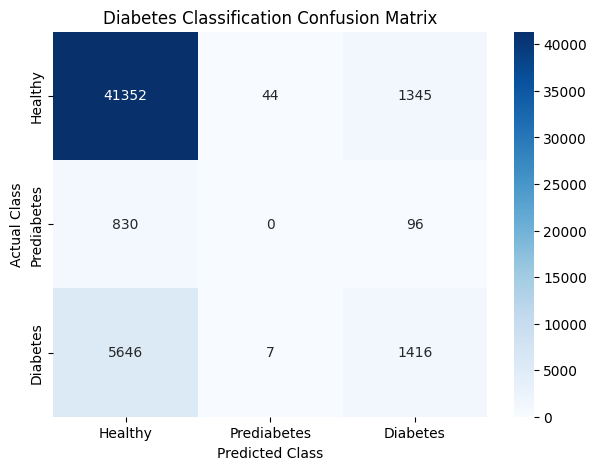

In [14]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Healthy",
        "Prediabetes",
        "Diabetes"
    ],
    yticklabels=[
        "Healthy",
        "Prediabetes",
        "Diabetes"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Diabetes Classification Confusion Matrix")

plt.show()

### 14. PREDICT A NEW PATIENT

In [17]:
patient = pd.DataFrame([[
    1,      # HighBP
    1,      # HighChol
    1,      # CholCheck
    28,     # BMI
    0,      # Smoker
    0,      # Stroke
    0,      # HeartDiseaseorAttack
    1,      # PhysActivity
    1,      # Fruits
    1,      # Veggies
    0,      # HvyAlcoholConsump
    1,      # AnyHealthcare
    0,      # NoDocbcCost
    2,      # GenHlth
    0,      # MentHlth
    0,      # PhysHlth
    0,      # DiffWalk
    1,      # Sex
    5,      # Age
    4,      # Education
    6       # Income
]], columns=X.columns)


# Standardize the new patient's data
patient_scaled = scaler.transform(patient)


# Make prediction
prediction = model.predict(patient_scaled)


# Convert prediction into class name
if prediction[0] == 0:
    result = "Healthy"

elif prediction[0] == 1:
    result = "Prediabetes"

else:
    result = "Diabetes"


print("\n--------------------------------")
print("NEW PATIENT PREDICTION")
print("--------------------------------")
print("Predicted class:", result)


--------------------------------
NEW PATIENT PREDICTION
--------------------------------
Predicted class: Healthy
